In [3]:
%pip install matplotlib numpy
%config IPCompleter.greedy=True

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np 
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [5]:
L = 1
alpha = 0.01
Nx = 50
dx = L/Nx
dt_max = 0.02
r = 0.4
dt = r * dt_max
T0 = 1

In [6]:
def distribuzione_sin(T0: float, x: float, t: float, alpha: float, L: float) -> float:
    T_in = T0 * np.sin(np.pi * x / L)
    return T0 * np.exp(-alpha * np.pi**2 * t / L**2) * np.sin(np.pi * x / L)

xs = np.linspace(0, L, Nx+1)

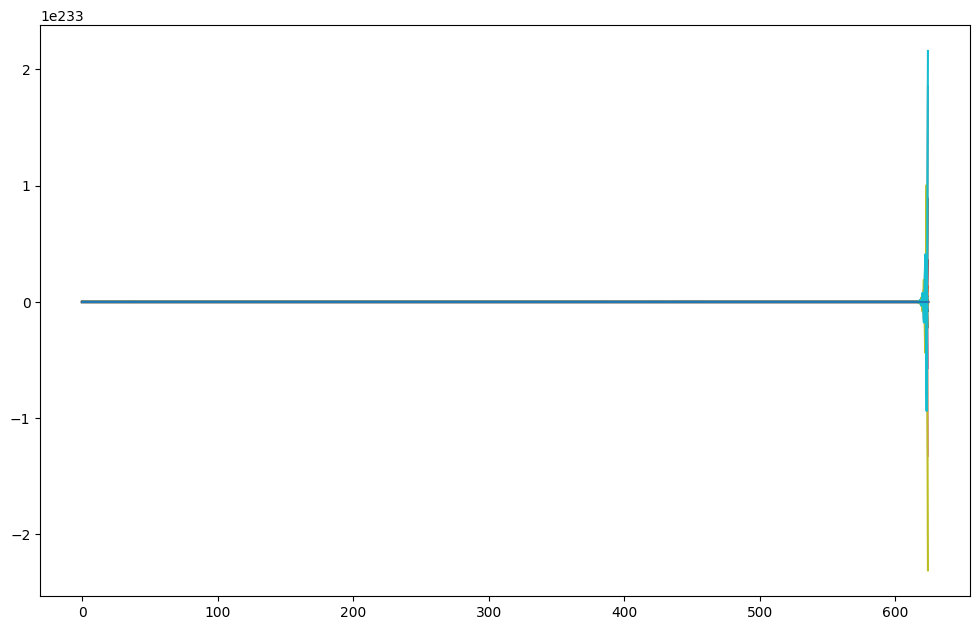

In [62]:
L = 1
alpha = 0.01
Nx = 50
dx = L/Nx
dt_max = 0.02
r = 0.4
dt = r * dt_max
T0 = 1

def ftcs(T0: float, Tf: float, x: list[float], t: float, dt: float, r: float, L: float) -> list[float]:
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.sin(np.pi * x / L)

    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j-1] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = T0, Tf    
    return Ts

Ts = ftcs(T0=1, Tf=0, x=xs, t=5, dt=dt, r=r, L=L)
plt.plot(Ts)
plt.show()